In [1]:
# STEP 1: Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Saving credit_card_frauds.csv to credit_card_frauds.csv
Dataset loaded successfully!
Dataset shape: (339607, 15)


In [2]:
# STEP 2: Basic dataset inspection

print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Columns:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']

First 5 rows:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud      

In [3]:
# STEP 3: Data quality check

print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [4]:
# STEP 4: Target distribution

print("Target column: is_fraud")
print(df['is_fraud'].value_counts())

print("\nTarget percentages:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

Target column: is_fraud
is_fraud
0    337825
1      1782
Name: count, dtype: int64

Target percentages:
is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64


In [5]:
# STEP 5: Examine dataset columns and data types

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nNumber of unique values in each column:")
print(df.nunique())

Column names:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']

Data types:
trans_date_trans_time     object
merchant                  object
category                  object
amt                      float64
city                      object
state                     object
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Number of unique values in each column:
trans_date_trans_time    338504
merchant                    693
category                     14
amt                       32112
city                        176
state                        13
lat                         183
long                        183


In [6]:
# STEP 6: Analyze transaction amounts

print("Transaction amount statistics:")
display(df['amt'].describe())

Transaction amount statistics:


,amt
count,339607.000000
mean,70.577984
std,161.675242
min,1.000000
25%,9.600000
50%,46.460000
75%,83.350000
max,28948.900000


In [7]:
# STEP 6.1: Compare transaction amounts for fraud and legitimate transactions

print("Average amount - Legitimate transactions:")
print(df.loc[df['is_fraud'] == 0, 'amt'].mean())

print("\nAverage amount - Fraudulent transactions:")
print(df.loc[df['is_fraud'] == 1, 'amt'].mean())

print("\nMedian amount - Legitimate transactions:")
print(df.loc[df['is_fraud'] == 0, 'amt'].median())

print("\nMedian amount - Fraudulent transactions:")
print(df.loc[df['is_fraud'] == 1, 'amt'].median())

Average amount - Legitimate transactions:
68.21752312587876

Average amount - Fraudulent transactions:
518.0654601571268

Median amount - Legitimate transactions:
46.25

Median amount - Fraudulent transactions:
356.435


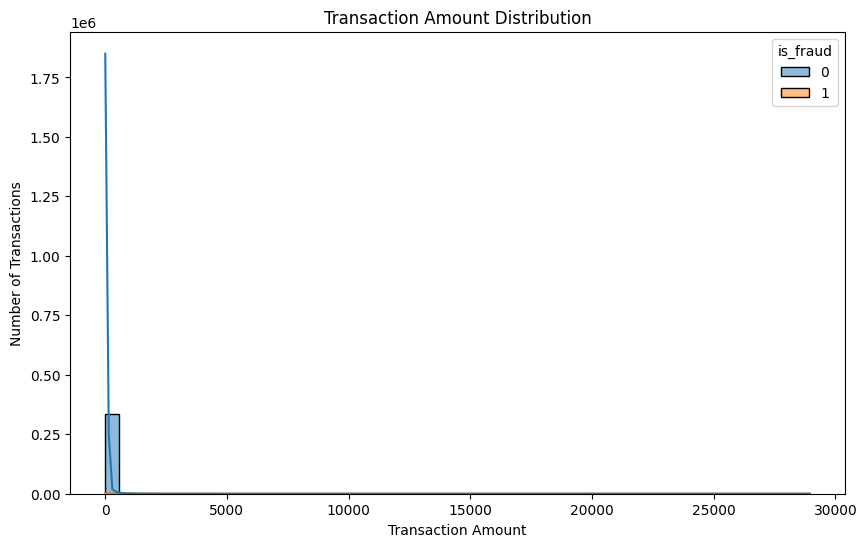

In [8]:
# STEP 6.2: Transaction amount distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='amt',
    hue='is_fraud',
    bins=50,
    kde=True
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')

plt.show()

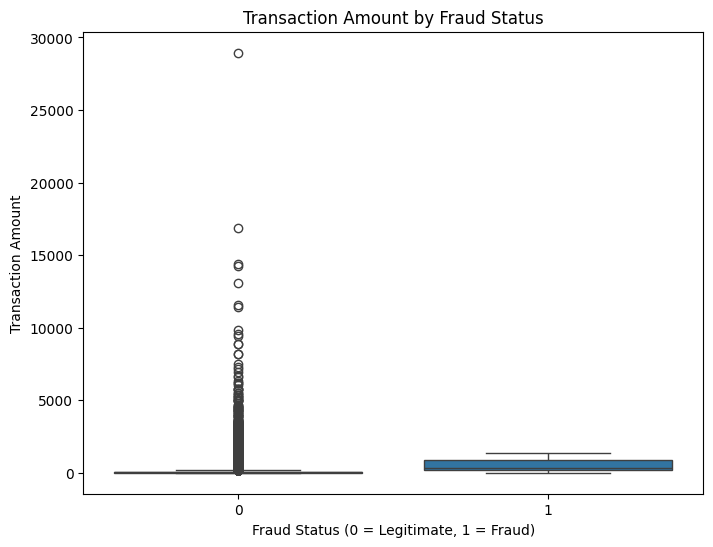

In [9]:
# STEP 6.3: Boxplot of transaction amounts by fraud status

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amt'
)

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')

plt.show()

In [10]:
# STEP 7: Fraud by transaction category

category_fraud = pd.crosstab(
    df['category'],
    df['is_fraud']
)

print("Fraud by category:")
display(category_fraud)

Fraud by category:


is_fraud,0,1
category,,
entertainment,24167,55
food_dining,23000,38
gas_transport,34936,153
grocery_net,11328,27
grocery_pos,32299,433
health_fitness,22557,36
home,32466,50
kids_pets,29649,55
misc_net,16681,217


In [11]:
# STEP 7.1: Fraud percentage within each category

category_fraud_rate = (
    df.groupby('category')['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Fraud rate by category:")
display(category_fraud_rate)

Fraud rate by category:


,is_fraud
category,
shopping_net,1.444331
grocery_pos,1.322864
misc_net,1.284176
shopping_pos,0.616572
gas_transport,0.436034
travel,0.319705
misc_pos,0.309628
grocery_net,0.237781
entertainment,0.227066


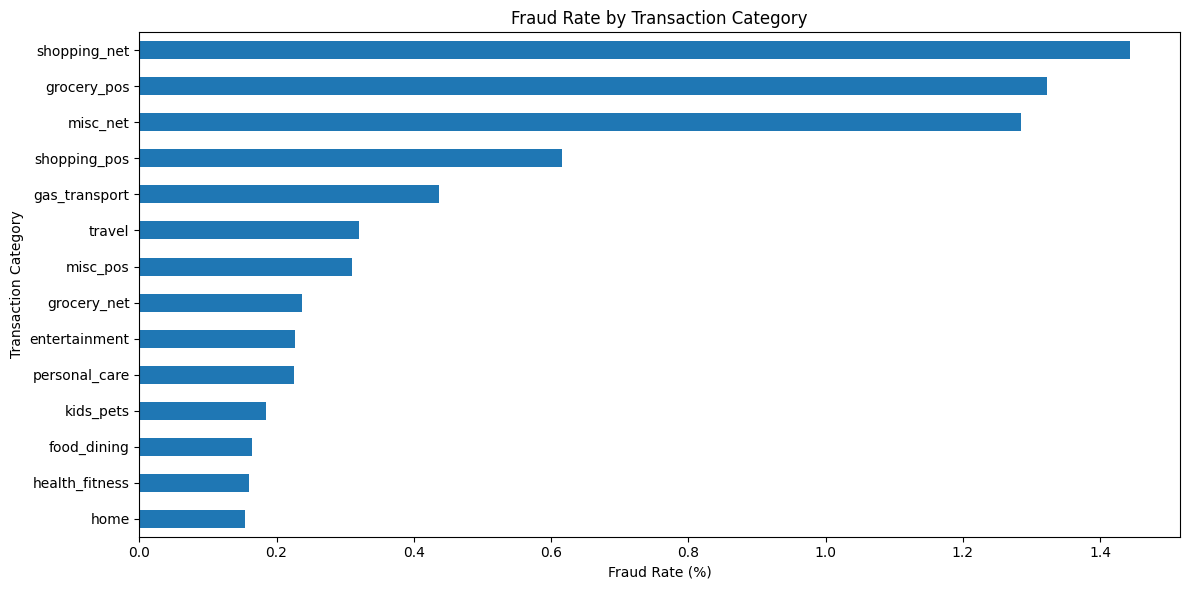

In [12]:
# STEP 7.2: Fraud rate by category

plt.figure(figsize=(12, 6))

category_fraud_rate.sort_values().plot(
    kind='barh'
)

plt.title('Fraud Rate by Transaction Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Transaction Category')

plt.tight_layout()
plt.show()

In [13]:
# STEP 8.1: Convert transaction date/time

df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time']
)

print("Date conversion successful!")

print("\nMinimum transaction date:")
print(df['trans_date_trans_time'].min())

print("\nMaximum transaction date:")
print(df['trans_date_trans_time'].max())

print("\nData type:")
print(df['trans_date_trans_time'].dtype)

Date conversion successful!

Minimum transaction date:
2019-01-01 00:00:44

Maximum transaction date:
2020-12-31 23:59:24

Data type:
datetime64[ns]


In [14]:
# STEP 8.2: Extract useful time features

df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df['transaction_day'] = df['trans_date_trans_time'].dt.day
df['transaction_month'] = df['trans_date_trans_time'].dt.month
df['transaction_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek

# Weekend indicator
df['is_weekend'] = (
    df['transaction_dayofweek'] >= 5
).astype(int)

print("New time features created!")

print("\nNew columns:")
print([
    'transaction_hour',
    'transaction_day',
    'transaction_month',
    'transaction_dayofweek',
    'is_weekend'
])

display(
    df[
        [
            'trans_date_trans_time',
            'transaction_hour',
            'transaction_day',
            'transaction_month',
            'transaction_dayofweek',
            'is_weekend'
        ]
    ].head()
)

New time features created!

New columns:
['transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'is_weekend']


,trans_date_trans_time,transaction_hour,transaction_day,transaction_month,transaction_dayofweek,is_weekend
0,2019-01-01 00:00:44,0,1,1,1,0
1,2019-01-01 00:00:51,0,1,1,1,0
2,2019-01-01 00:07:27,0,1,1,1,0
3,2019-01-01 00:09:03,0,1,1,1,0
4,2019-01-01 00:21:32,0,1,1,1,0


In [15]:
# STEP 8.3: Fraud rate by transaction hour

hourly_fraud_rate = (
    df.groupby('transaction_hour')['is_fraud']
    .mean() * 100
)

print("Fraud rate by hour:")
display(hourly_fraud_rate)

Fraud rate by hour:


,is_fraud
transaction_hour,
0,1.521877
1,1.494529
2,1.270533
3,1.273715
4,0.064197
5,0.090719
6,0.062808
7,0.081125
8,0.107885


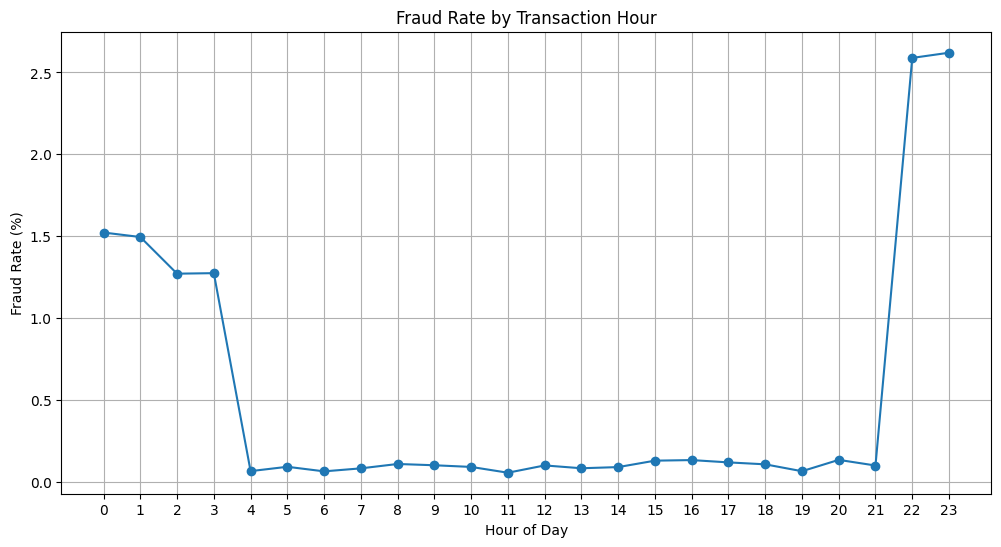

In [16]:
# STEP 8.4: Visualization of fraud rate by hour

plt.figure(figsize=(12, 6))

hourly_fraud_rate.plot(kind='line', marker='o')

plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [17]:
# STEP 9.1: Fraud rate by state

state_fraud_rate = (
    df.groupby('state')['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Fraud rate by state:")
display(state_fraud_rate)

Fraud rate by state:


,is_fraud
state,
AK,1.687479
OR,0.745986
NE,0.627451
CO,0.581807
NM,0.516498
CA,0.499410
MO,0.477197
WA,0.465976
HI,0.438476


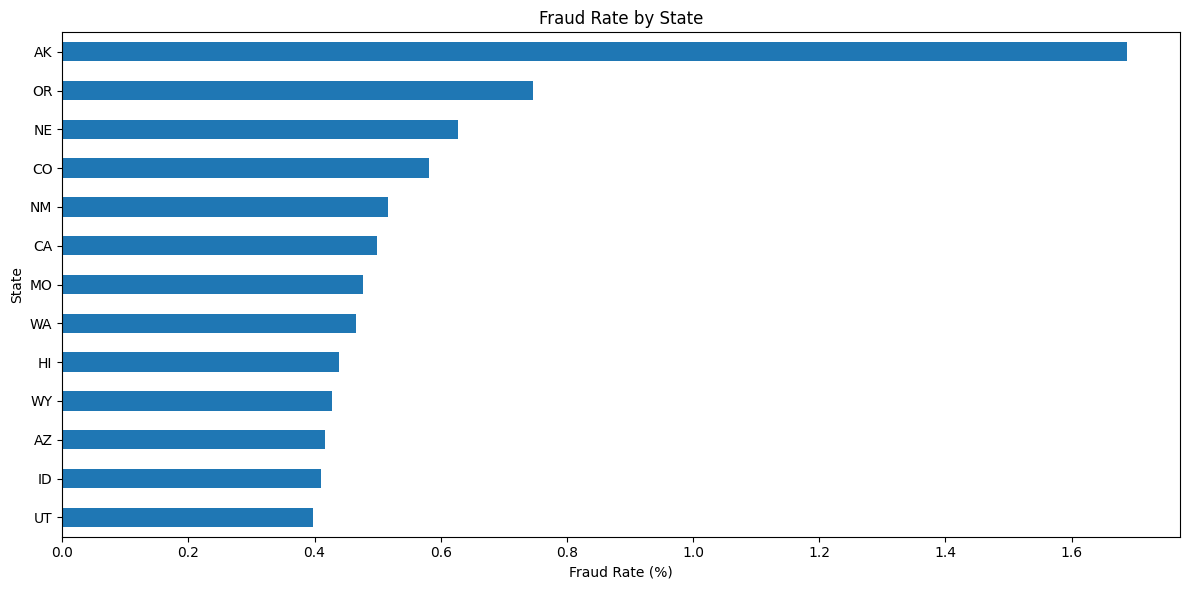

In [18]:
# STEP 9.2: Visualize fraud rate by state

plt.figure(figsize=(12, 6))

state_fraud_rate.sort_values().plot(kind='barh')

plt.title('Fraud Rate by State')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [19]:
# STEP 9.3: Compare city population by fraud status

print("Average city population - Legitimate:")
print(df.loc[df['is_fraud'] == 0, 'city_pop'].mean())

print("\nAverage city population - Fraud:")
print(df.loc[df['is_fraud'] == 1, 'city_pop'].mean())

print("\nMedian city population - Legitimate:")
print(df.loc[df['is_fraud'] == 0, 'city_pop'].median())

print("\nMedian city population - Fraud:")
print(df.loc[df['is_fraud'] == 1, 'city_pop'].median())

Average city population - Legitimate:
107091.10958040405

Average city population - Fraud:
116573.41245791246

Median city population - Legitimate:
1645.0

Median city population - Fraud:
1645.0


In [20]:
# ============================================================
# STEP 9: FEATURE ENGINEERING
# ============================================================

# Make sure date columns are datetime
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    errors='coerce'
)

df['dob'] = pd.to_datetime(
    df['dob'],
    errors='coerce'
)

# Customer age at time of transaction
df['customer_age'] = (
    (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
)

# Distance between customer and merchant
# Haversine approximation
lat1 = np.radians(df['lat'])
lon1 = np.radians(df['long'])
lat2 = np.radians(df['merch_lat'])
lon2 = np.radians(df['merch_long'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

earth_radius_km = 6371

df['distance_km'] = earth_radius_km * c

print("Feature engineering completed!")

print("\nNew features:")
print("customer_age")
print("distance_km")

display(
    df[
        [
            'customer_age',
            'distance_km',
            'transaction_hour',
            'transaction_dayofweek',
            'is_weekend'
        ]
    ].head()
)

Feature engineering completed!

New features:
customer_age
distance_km


,customer_age,distance_km,transaction_hour,transaction_dayofweek,is_weekend
0,40.531143,30.212176,0,1,0
1,56.950034,108.206083,0,1,0
2,73.029432,25.059079,0,1,0
3,51.340178,66.021685,0,1,0
4,51.416838,88.830984,0,1,0


In [21]:
# ============================================================
# STEP 10: FINAL FEATURES AND TARGET
# ============================================================

target = 'is_fraud'

drop_columns = [
    'is_fraud',
    'trans_num',
    'trans_date_trans_time',
    'dob'
]

X = df.drop(columns=drop_columns).copy()
y = df[target].astype(int).copy()

print("Features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Number of records:", X.shape[0])

print("\nTarget distribution:")
print(y.value_counts())

Features:
['merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'is_weekend', 'customer_age', 'distance_km']

Number of features: 18
Number of records: 339607

Target distribution:
is_fraud
0    337825
1      1782
Name: count, dtype: int64


In [22]:
# ============================================================
# STEP 11: TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test split completed!")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFraud distribution in training:")
print(y_train.value_counts())

print("\nFraud distribution in testing:")
print(y_test.value_counts())

Train/Test split completed!

Training data:
X_train: (271685, 18)
y_train: (271685,)

Testing data:
X_test: (67922, 18)
y_test: (67922,)

Fraud distribution in training:
is_fraud
0    270259
1      1426
Name: count, dtype: int64

Fraud distribution in testing:
is_fraud
0    67566
1      356
Name: count, dtype: int64


In [23]:
# ============================================================
# STEP 12: PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_weekend', 'customer_age', 'distance_km']

Categorical features:
['merchant', 'category', 'city', 'state', 'job']

Number of numerical features: 9
Number of categorical features: 5


In [24]:
# Create preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [25]:
# ============================================================
# STEP 13: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [26]:
# ============================================================
# STEP 14: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=150,
                max_depth=20,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [27]:
# ============================================================
# STEP 15: MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, model_name):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )
    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"Average Precision : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'average_precision': pr_auc
    }

In [28]:
# Evaluate Logistic Regression

logistic_results = evaluate_model(
    logistic_model,
    "Logistic Regression"
)

Logistic Regression
Accuracy          : 0.8901
Precision         : 0.0346
Recall            : 0.7416
F1 Score          : 0.0661
ROC-AUC           : 0.8728
Average Precision : 0.1530

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     67566
           1       0.03      0.74      0.07       356

    accuracy                           0.89     67922
   macro avg       0.52      0.82      0.50     67922
weighted avg       0.99      0.89      0.94     67922

Confusion Matrix:
[[60195  7371]
 [   92   264]]


In [29]:
# Evaluate Random Forest

random_forest_results = evaluate_model(
    random_forest_model,
    "Random Forest"
)

Random Forest
Accuracy          : 0.9838
Precision         : 0.2038
Recall            : 0.7163
F1 Score          : 0.3174
ROC-AUC           : 0.9328
Average Precision : 0.5961

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     67566
           1       0.20      0.72      0.32       356

    accuracy                           0.98     67922
   macro avg       0.60      0.85      0.65     67922
weighted avg       0.99      0.98      0.99     67922

Confusion Matrix:
[[66570   996]
 [  101   255]]


In [30]:
# ============================================================
# STEP 16: MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    logistic_results,
    random_forest_results
])

display(
    results.sort_values(
        by='f1',
        ascending=False
    )
)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
1,Random Forest,0.983849,0.203837,0.716292,0.317362,0.932804,0.596136
0,Logistic Regression,0.890124,0.034578,0.741573,0.066074,0.872780,0.153013


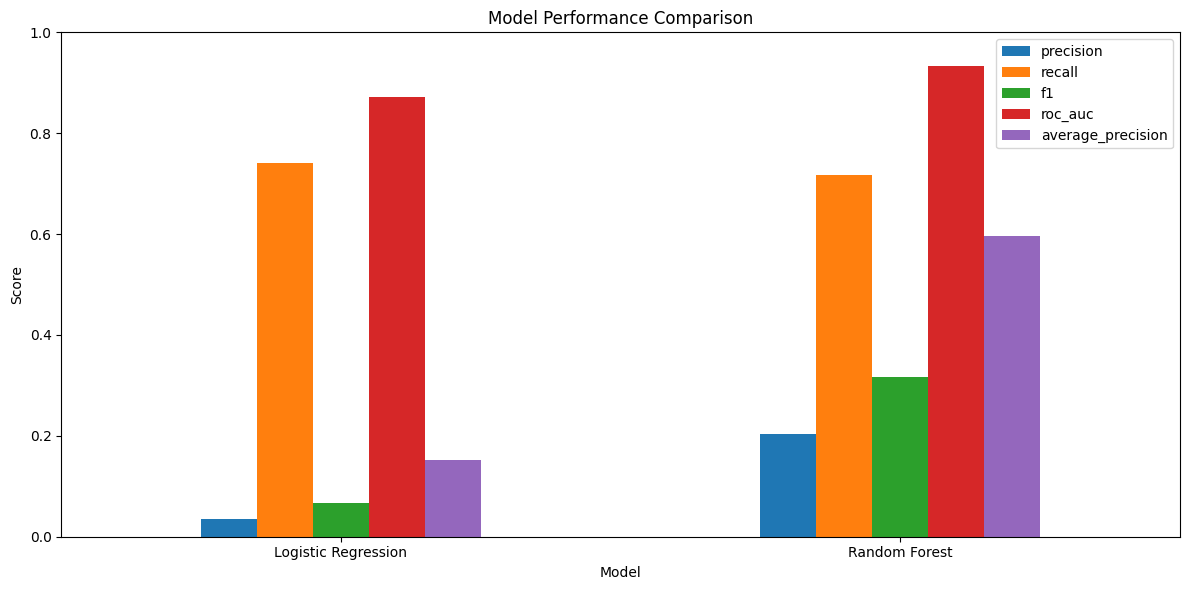

In [31]:
# Model comparison chart

results_plot = results.set_index('model')[
    [
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ]
]

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
final_model = random_forest_model
final_model_name = "Random Forest"

In [33]:
final_model = logistic_model
final_model_name = "Logistic Regression"

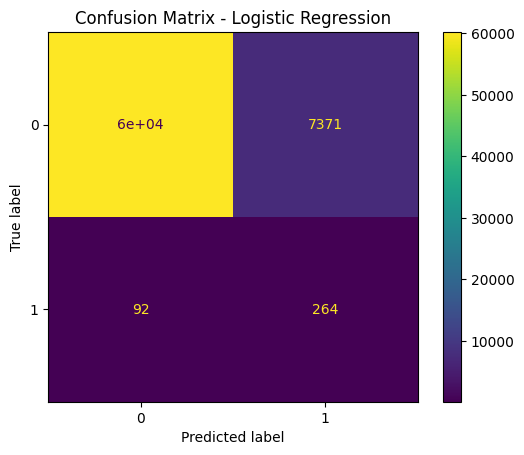

In [34]:
# ============================================================
# STEP 17: FINAL MODEL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

y_final_pred = final_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_final_pred
)

plt.title(f'Confusion Matrix - {final_model_name}')
plt.show()

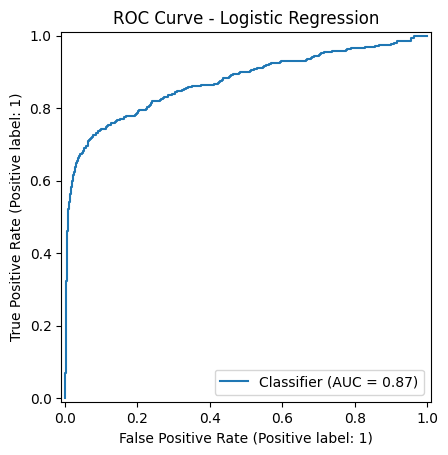

In [35]:
# ============================================================
# STEP 18: ROC CURVE
# ============================================================

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    final_model.predict_proba(X_test)[:, 1]
)

plt.title(f'ROC Curve - {final_model_name}')
plt.show()

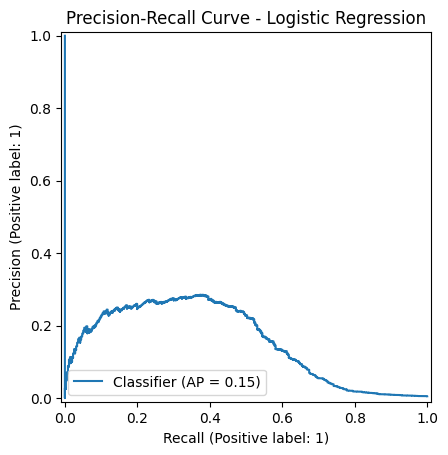

In [36]:
# ============================================================
# STEP 19: PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    final_model.predict_proba(X_test)[:, 1]
)

plt.title(
    f'Precision-Recall Curve - {final_model_name}'
)

plt.show()

In [37]:
# ============================================================
# STEP 20: SAVE FINAL MODEL
# ============================================================

import joblib

joblib.dump(
    final_model,
    'credit_card_fraud_model.pkl'
)

print("Model saved successfully!")
print("File: credit_card_fraud_model.pkl")

Model saved successfully!
File: credit_card_fraud_model.pkl


In [38]:
from google.colab import files

files.download('credit_card_fraud_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# ============================================================
# STEP 21: TEST SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    'credit_card_fraud_model.pkl'
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Fraud probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("Result: FRAUDULENT TRANSACTION")
else:
    print("Result: LEGITIMATE TRANSACTION")

Prediction: 0
Fraud probability: 13.41 %
Result: LEGITIMATE TRANSACTION


In [40]:
# ============================================================
# STEP 22: SAVE MODEL RESULTS
# ============================================================

results.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [41]:
# ============================================================
# STEP 23: PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("CREDIT CARD FRAUD DETECTION PROJECT")
print("=" * 70)

print("\nDataset:")
print(f"Total transactions: {len(df):,}")
print(f"Total features before engineering: 14")
print(f"Fraudulent transactions: {y.sum():,}")
print(f"Legitimate transactions: {(y == 0).sum():,}")

print("\nFinal model:")
print(final_model_name)

print("\nModel results:")
display(results)

CREDIT CARD FRAUD DETECTION PROJECT

Dataset:
Total transactions: 339,607
Total features before engineering: 14
Fraudulent transactions: 1,782
Legitimate transactions: 337,825

Final model:
Logistic Regression

Model results:


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.890124,0.034578,0.741573,0.066074,0.872780,0.153013
1,Random Forest,0.983849,0.203837,0.716292,0.317362,0.932804,0.596136
